#### Analyzing the simulations with $\beta = 45\degree$ and $q_2 = 10^{-5}$:
#### $s = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, \dfrac{1}{0.9}, \dfrac{1}{0.8}, \dfrac{1}{0.7}, \dfrac{1}{0.6}, \dfrac{1}{0.5}]$

$$
\vec{\delta}_{1,rotated} \equiv \begin{bmatrix} \dfrac{q_1} {(1 + q_1)(s_1 + \dfrac{1}{s_1})} \\ 0 \end{bmatrix}
$$

$$
\vec{\delta}_{2,rotated} \equiv \begin{bmatrix} \dfrac{q_2} {(1 + q_2)(s_2 + \dfrac{1}{s_2})} \\ 0 \end{bmatrix}
$$

$$
R_1 = \begin{bmatrix} \cos{\beta_1} & -\sin{\beta_1} \\ \sin{\beta_1} & \cos{\beta_1} \end{bmatrix}
$$

$$
R_2 = \begin{bmatrix} \cos{\beta_2} & -\sin{\beta_2} \\ \sin{\beta_2} & \cos{\beta_2} \end{bmatrix}
$$

$$
\vec{\delta}_{1} = R_1 \cdot \vec{\delta}_{1,rotated}
$$

$$
\vec{\delta}_{2} = R_2 \cdot \vec{\delta}_{2,rotated}
$$

$$
\vec{\delta}_{binary} = \vec{\delta}_{1}
$$

$$
\vec{\delta}_{triple} = \dfrac{q_1 \vec{\delta}_{1} + q_2 \vec{\delta}_{2}}{q_1 + q_2}
$$

$$
\vec{s}_{1} \equiv \begin{bmatrix} s_1 \cos{\beta_1} \\ s_1 \sin{\beta_1} \end{bmatrix}
$$

$$
\vec{s}_{2} \equiv \begin{bmatrix} s_2 \cos{\beta_2} \\ s_2 \sin{\beta_2} \end{bmatrix}
$$

$$
\vec{\delta}_{CM} = \dfrac{q_1 \vec{s}_{1} + q_2 \vec{s}_{2}}{q_1 + q_2}
$$

In [1]:
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

%load_ext autoreload
%autoreload 2

import pickle
import time as t
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

init_time = t.time()
from IRSMicroLensing import IRSCaustics as IRSC
from IRSMicroLensing import IRSFunctions as IRSF
print(f'Custom library import time: {(t.time() - init_time):.3} seconds')

import VBMicrolensing
import numexpr
import MulensModel as mm

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

Custom library import time: 1.64 seconds


#### Initializing VBMicrolensing

In [2]:
VBM = VBMicrolensing.VBMicrolensing()

# Set relative accuracy
VBM.RelTol = 1e-03

# Set accuracy
VBM.Tol=1e-03

#### Importing all simulations and checking parameters

In [3]:
# Single lens
single_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/single_1e11.pkl')

# Binary lens
binary_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/binary_1e11.pkl')

# All triple lens
seperations = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1/0.9, 1/0.8, 1/0.7, 1/0.6, 1/0.5]
seperations_str = ['0.5', '0.6', '0.7', '0.8', '0.9', '1.0', '1/0.9', '1/0.8', '1/0.7', '1/0.6', '1/0.5']

triple_lenses = []
triple_lenses_binary_offset = []
triple_lenses_cm_offset = []

for s in seperations:
    file_path = f'../Unity/Simulations/Collection_pmr_0.01/triple_1e11_{s:.2e}_triple_offset.pkl'
    triple_lenses.append(IRSC.caustic_reader(file_path))

    print(file_path)

    file_path = f'../Unity/Simulations/Collection_pmr_0.01/triple_1e11_{s:.2e}_binary_offset.pkl'
    triple_lenses_binary_offset.append(IRSC.caustic_reader(file_path))

    file_path = f'../Unity/Simulations/Collection_pmr_0.01/triple_1e11_{s:.2e}_cm.pkl'
    triple_lenses_cm_offset.append(IRSC.caustic_reader(file_path))

triple_lenses = np.array(triple_lenses)
triple_lenses_binary_offset = np.array(triple_lenses_binary_offset)
triple_lenses_cm_offset = np.array(triple_lenses_cm_offset)

../Unity/Simulations/Collection_pmr_0.01/triple_1e11_5.00e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_6.00e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_7.00e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_8.00e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_9.00e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_1.00e+00_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_1.11e+00_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_1.25e+00_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_1.43e+00_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_1.67e+00_triple_offset.pkl
../Unity/Simulations/Collection_pmr_0.01/triple_1e11_2.00e+00_triple_offset.pkl


#### Verifying lens locations

In [4]:
args = {
    'sep2': '0.5',
    'angle2': '45',
    'planet_mass_ratio': '0.01',
    'origin': 'triple_offset'  # Options: 'triple_offset', 'binary_offset', 'cm'

}

''' Preparing lens parameters '''
# Big planet parameters
s1 = 0.8
alpha1 = 0
q1 = 1e-3

# Small planet parameters
s2 = np.float64(numexpr.evaluate(args['sep2']).item())
alpha2 = np.float64(args['angle2'])
q2 = np.float64(args['planet_mass_ratio']) * q1

print(f'q1 = {q1}')
print(f'q2 = {q2}')
print(f's1 = {s1}')
print(f's2 = {s2}')
print(f'alpha1 = {alpha1}')
print(f'alpha2 = {alpha2}')

# Defining single lens attributes
single_lens_attributes = np.array([
    [0, 0, 1]
])

# Defining binary lens attributes
binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Triple lens attributes
triple_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
    [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2]
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Rotation matrix for second planet
second_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha2)), -np.sin(np.deg2rad(alpha2))],
    [np.sin(np.deg2rad(alpha2)), np.cos(np.deg2rad(alpha2))]
])

# Calculating translation of coordinate origin for each planet
q1 = triple_lens_attributes[1, 2]
q2 = triple_lens_attributes[2, 2]

delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta2_rot = np.array([q2 / ((1 + q2) * (s2 + 1/s2)), 0]).reshape(-1, 1)

delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
delta2 = np.dot(second_planet_DCM, delta2_rot).reshape(2)

total_offset = (q1*delta1 + q2*delta2)/(q1 + q2)
print(f'Total offset: {total_offset}')
print(f'Binary offset: {delta1}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1

# Correcting triple lens attributes
if args['origin'] == 'triple_offset':
    triple_lens_attributes[:, :2] -= total_offset
elif args['origin'] == 'binary_offset':
    triple_lens_attributes[:, :2] -= delta1
elif args['origin'] == 'cm':
    CM_sum = 0

    for i in range(3):
        CM_sum += triple_lens_attributes[i, :2] * triple_lens_attributes[i, 2]

    total_M = np.sum(triple_lens_attributes[:, 2])

    lens_CM = CM_sum / total_M

    triple_lens_attributes[:, :2] -= lens_CM

else:
    raise ValueError(f'Wrong origin passed in. Got {args["origin"]}.')

# Map parameters
pixels = 2000
delta = 0.01

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(triple_lens_attributes)
num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

print(f'Angular width: {ang_width}')
print(f'Thickness: {thickness}')
print(f'Annulus lower bound: {y_minus}')
print(f'Annulus upper bound: {y_plus}')
print(f'Number of rays in theta: {num_theta}')
print(f'Number of rays in r: {num_r}')

q1 = 0.001
q2 = 1e-05
s1 = 0.8
s2 = 0.5
alpha1 = 0
alpha2 = 45.0
Total offset: [4.82520638e-04 2.80039489e-08]
Binary offset: [0.00048732 0.        ]
Angular width: 0.07680319680319682
Thickness: 0.059738867403980045
Annulus lower bound: -0.970576558378381
Annulus upper bound: 1.030315425782361
Number of rays in theta: 194884
Number of rays in r: 779536


In [5]:
print(f'Angular width of single lens: {single_lens.ang_width}')
print(f'Angular width of binary lens: {binary_lens.ang_width}')

ang_width = single_lens.ang_width
pixels = single_lens.pixels
ang_res = single_lens.ang_res

# for triple_lens in triple_lenses:
#     print(triple_lens.lens_att)

print(triple_lenses[0].lens_att)
print(triple_lenses_binary_offset[0].lens_att)

Angular width of single lens: 0.07680319680319682
Angular width of binary lens: 0.07680319680319682
[[-4.82520638e-04 -2.80039489e-08  1.00000000e+00]
 [ 7.99517479e-01 -2.80039489e-08  1.00000000e-03]
 [ 3.53070870e-01  3.53553363e-01  1.00000000e-05]]
[[-4.87317560e-04  0.00000000e+00  1.00000000e+00]
 [ 7.99512682e-01  0.00000000e+00  1.00000000e-03]
 [ 3.53066073e-01  3.53553391e-01  1.00000000e-05]]


#### Plotting single and binary lens simulations

Plotting magnification map: 0.055 seconds
Plotting magnification map: 0.028 seconds


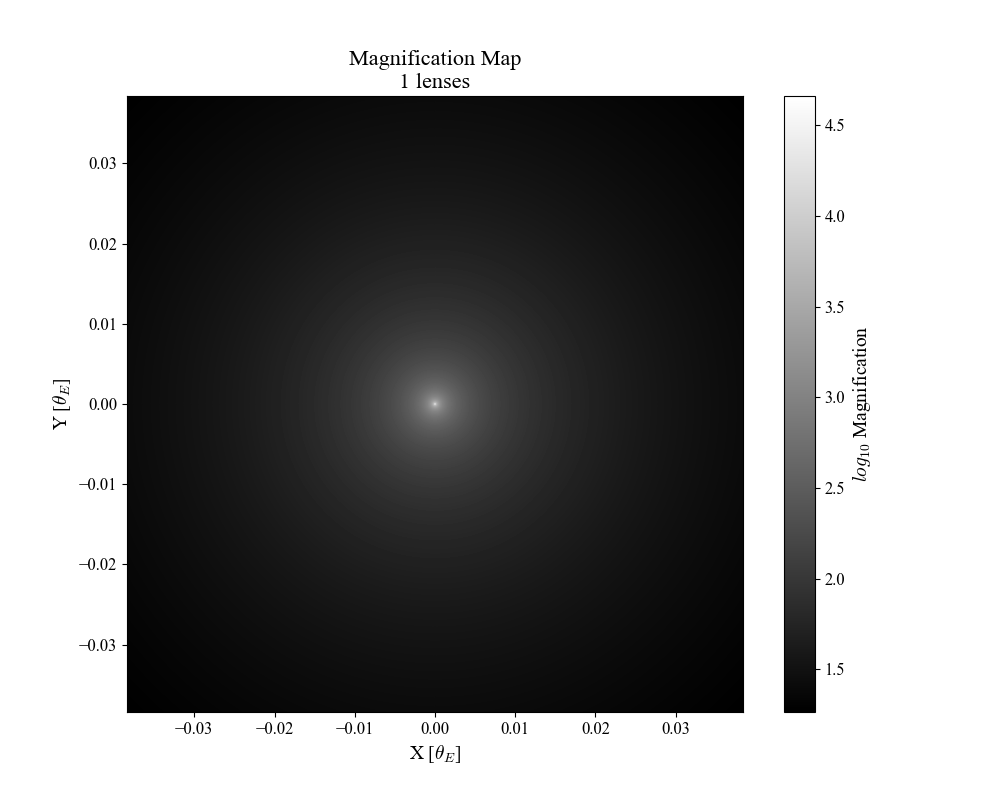

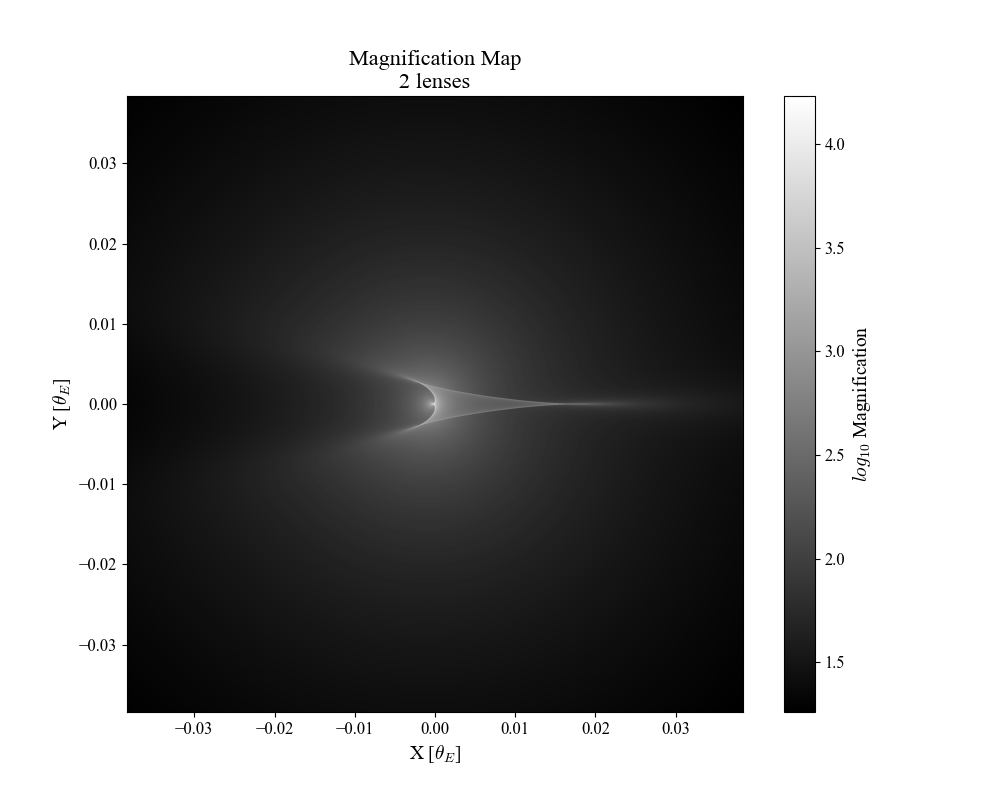

In [6]:
# Single lens
single_lens.plot()

# Binary lens
binary_lens.plot()

#### Calculating VBMicrolensing caustics

In [7]:
all_caustic_points = []
all_caustic_points_binary_offset = []
all_caustic_points_cm_offset = []

for triple_lens in triple_lenses:
    parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
    VBM.SetLensGeometry(parameters)

    caustic_points = VBM.Multicaustics()

    all_caustic_points.append(caustic_points)

for triple_lens in triple_lenses_binary_offset:
    parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
    VBM.SetLensGeometry(parameters)

    caustic_points = VBM.Multicaustics()
    
    all_caustic_points_binary_offset.append(caustic_points)

for triple_lens in triple_lenses_cm_offset:
    parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
    VBM.SetLensGeometry(parameters)

    caustic_points = VBM.Multicaustics()
    
    all_caustic_points_cm_offset.append(caustic_points)

#### Defining source parameters

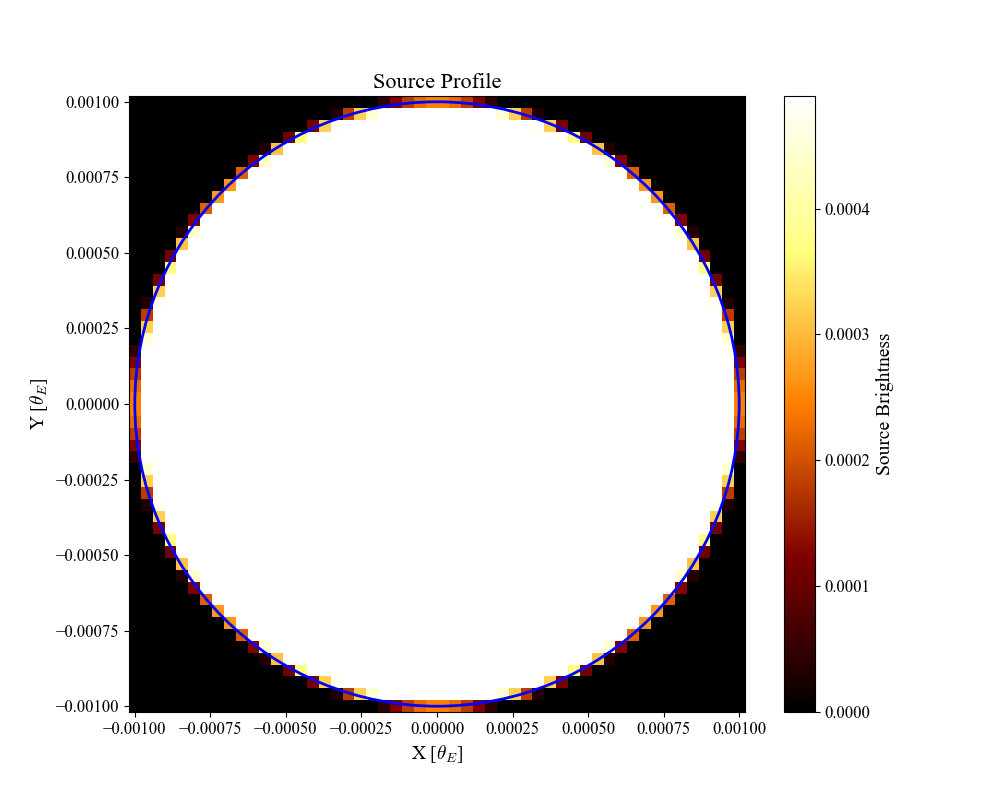

In [ ]:
radius = 1e-3
LD = 0.5

source_profile = IRSF.IRSFunctions.source_profile(ang_res=single_lens.param_dict['ang_res'], rad=radius, profile_type='uniform', LD=LD)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(source_profile, cmap='afmhot', extent=[-radius - ang_res / 2, radius + ang_res / 2, -radius - ang_res / 2, radius + ang_res / 2])
plt.colorbar(img, ax=ax, label='Source Brightness')

source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)

ax.set_xlabel('X [$\\theta_E$]')
ax.set_ylabel('Y [$\\theta_E$]')
ax.set_title('Source Profile')

ax.set_aspect('equal')

plt.show()

In [96]:
print(source_profile.shape)
print(np.sum(source_profile))

(52, 52)
0.9999999999999998


#### Convolving all lens configurations

In [97]:
# Single lens
convolved_single_lens = single_lens.convolve(source_profile=source_profile)

# Binary lens
convolved_binary_lens = binary_lens.convolve(source_profile=source_profile)

# All triple lenses
convolved_triple_lenses = []
convolved_triple_lenses_cm_offset = []
convolved_triple_lenses_binary_offset = []

for triple_lens in triple_lenses:
    convolved_triple_lens = triple_lens.convolve(source_profile=source_profile)
    
    convolved_triple_lenses.append(convolved_triple_lens)

for triple_lens in triple_lenses_binary_offset:
    convolved_triple_lens_binary_offset = triple_lens.convolve(source_profile=source_profile)
    
    convolved_triple_lenses_binary_offset.append(convolved_triple_lens_binary_offset)

for triple_lens in triple_lenses_cm_offset:
    convolved_triple_lens_cm_offset = triple_lens.convolve(source_profile=source_profile)
    
    convolved_triple_lenses_cm_offset.append(convolved_triple_lens_cm_offset)

convolved_triple_lenses = np.array(convolved_triple_lenses)
convolved_triple_lenses_binary_offset = np.array(convolved_triple_lenses_binary_offset)
convolved_triple_lenses_cm_offset = np.array(convolved_triple_lenses_cm_offset)

Convolving source profile with magnification map: 0.312 seconds
Convolving source profile with magnification map: 0.237 seconds
Convolving source profile with magnification map: 0.252 seconds
Convolving source profile with magnification map: 0.241 seconds
Convolving source profile with magnification map: 0.23 seconds
Convolving source profile with magnification map: 0.259 seconds
Convolving source profile with magnification map: 0.236 seconds
Convolving source profile with magnification map: 0.233 seconds
Convolving source profile with magnification map: 0.259 seconds
Convolving source profile with magnification map: 0.162 seconds
Convolving source profile with magnification map: 0.156 seconds
Convolving source profile with magnification map: 0.152 seconds
Convolving source profile with magnification map: 0.157 seconds
Convolving source profile with magnification map: 0.153 seconds
Convolving source profile with magnification map: 0.182 seconds
Convolving source profile with magnificat

#### Calculating fractional deviations from single and binary for all triple lens configurations

In [98]:
# Single lens deviations
fractional_deviation_single = []
fractional_deviation_single_binary_offset = []
fractional_deviation_single_cm_offset = []

# Binary lens deviations
fractional_deviation_binary = []
fractional_deviation_binary_binary_offset = []
fractional_deviation_binary_cm_offset = []

for convolved_triple_lens in convolved_triple_lenses:
    fractional_deviation_single.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
    fractional_deviation_binary.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

for convolved_triple_lens in convolved_triple_lenses_binary_offset:
    fractional_deviation_single_binary_offset.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
    fractional_deviation_binary_binary_offset.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

for convolved_triple_lens in convolved_triple_lenses_cm_offset:
    fractional_deviation_single_cm_offset.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
    fractional_deviation_binary_cm_offset.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

fractional_deviation_single = np.array(fractional_deviation_single)
fractional_deviation_single_binary_offset = np.array(fractional_deviation_single_binary_offset)
fractional_deviation_single_cm_offset = np.array(fractional_deviation_single_cm_offset)

fractional_deviation_binary = np.array(fractional_deviation_binary)
fractional_deviation_binary_binary_offset = np.array(fractional_deviation_binary_binary_offset)
fractional_deviation_binary_cm_offset = np.array(fractional_deviation_binary_cm_offset)

In [99]:
print(fractional_deviation_single.shape)
print(fractional_deviation_single_binary_offset.shape)
print(fractional_deviation_single_cm_offset.shape)

print(fractional_deviation_binary.shape)
print(fractional_deviation_binary_binary_offset.shape)
print(fractional_deviation_binary_cm_offset.shape)

(11, 2000, 2000)
(11, 2000, 2000)
(11, 2000, 2000)
(11, 2000, 2000)
(11, 2000, 2000)
(11, 2000, 2000)


#### Plotting all fractional deviations

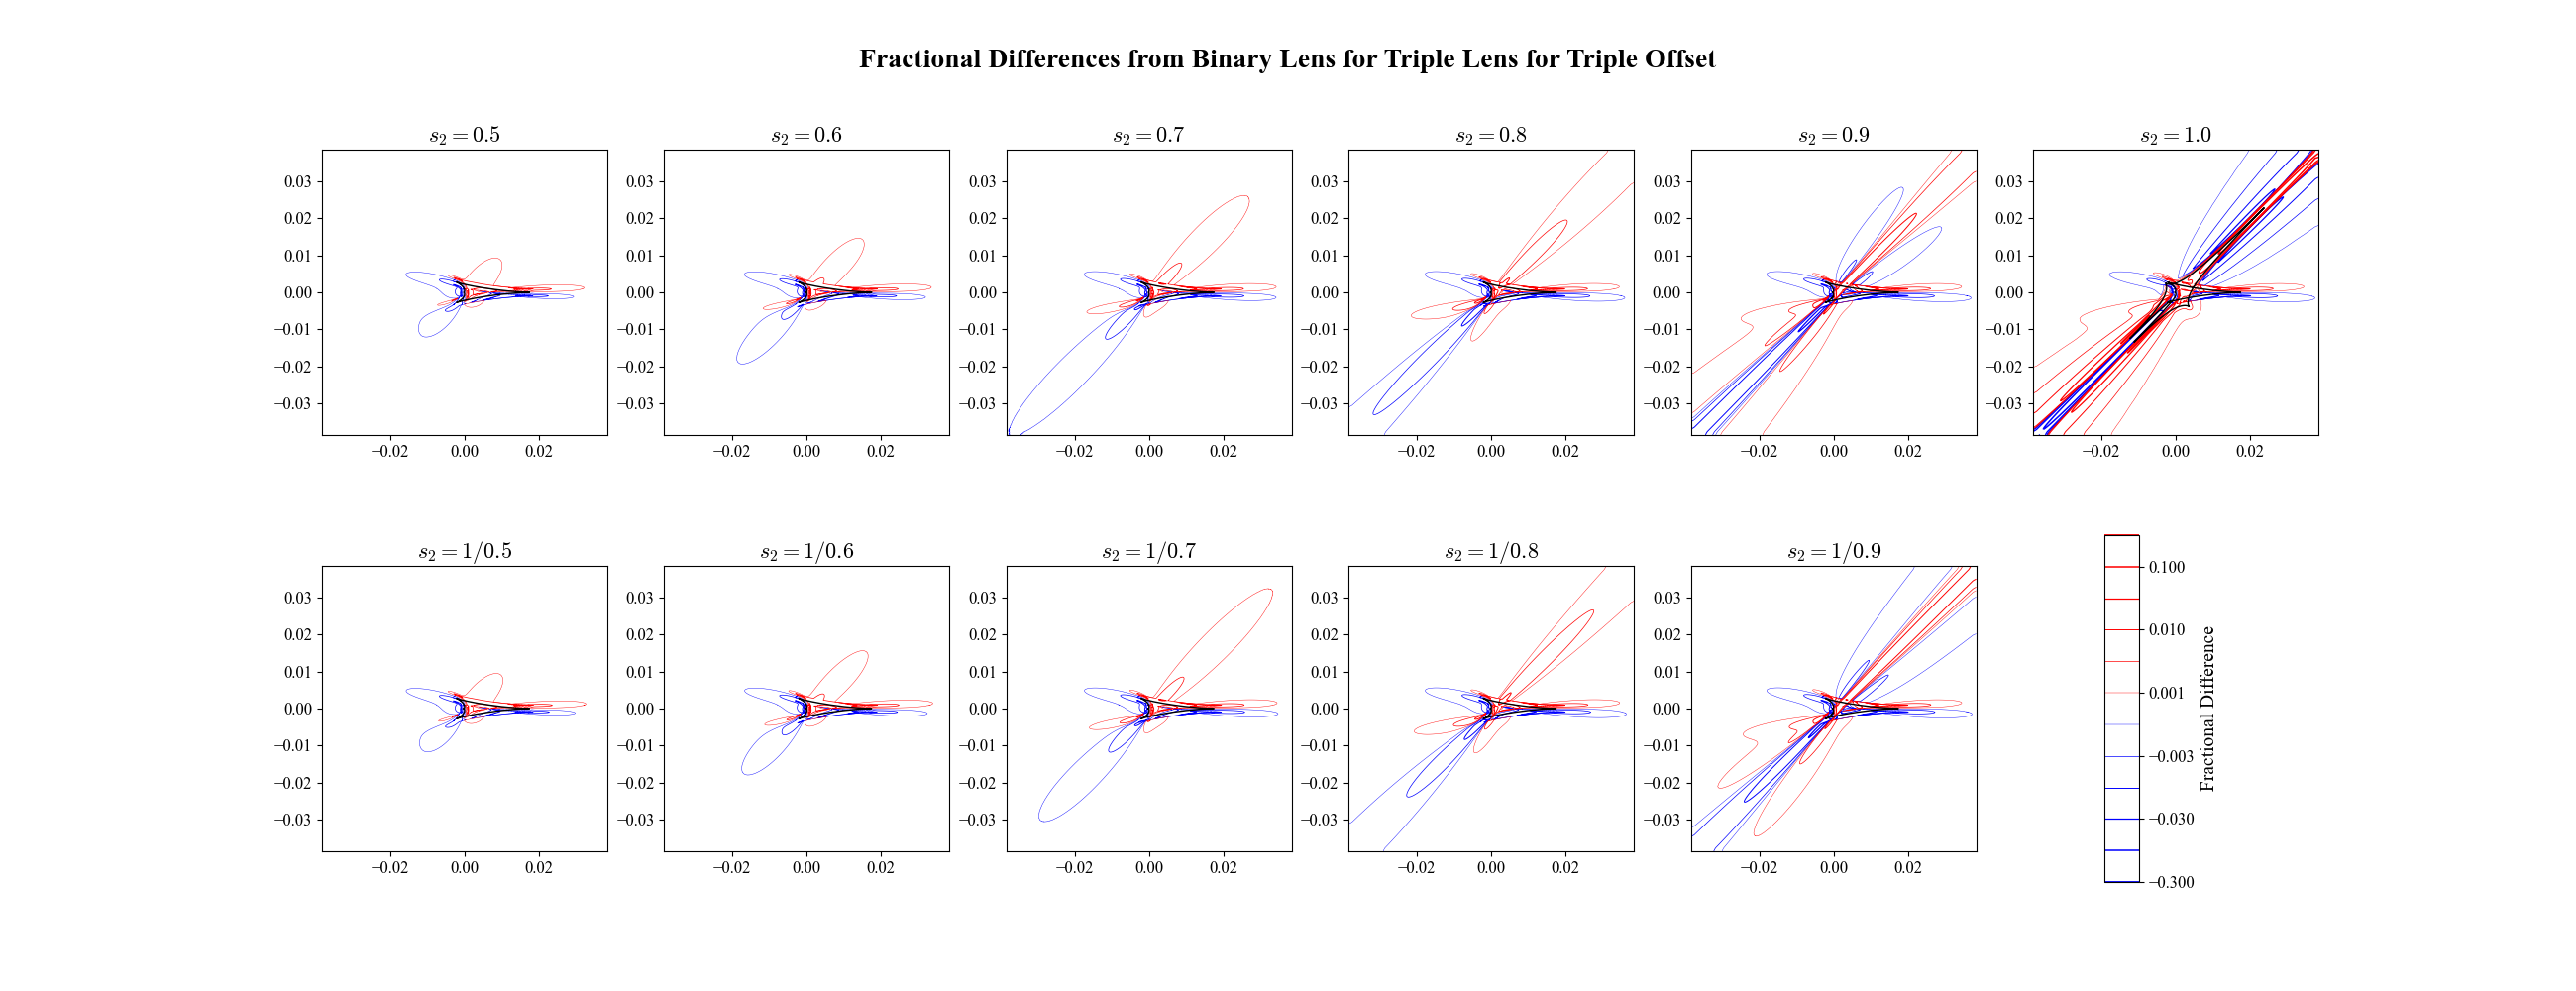

In [100]:
fig = plt.figure(figsize=(26, 10))
axes = fig.subplots(2, 6)

fig.suptitle('Fractional Differences from Binary Lens for Triple Lens for Triple Offset', y=0.95)

for i, ax in enumerate(axes.flatten()):
    if i <= 5:
        ax.set_title(f'$s_2 = {seperations_str[i]}$')

        caustic_points = all_caustic_points[i]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary[i], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        ax.set_aspect('equal')
    
    elif i <= 10:
        backwards_i = -i + 16

        ax.set_title(f'$s_2 = {seperations_str[backwards_i]}$')

        caustic_points = all_caustic_points[backwards_i]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary[backwards_i], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        ax.set_aspect('equal')
        

    if i == 11:
        cbar_ax = ax
        cbar_ax.axis('off')

        bar = fig.colorbar(img, ax=cbar_ax, fraction=0.75, aspect=10)
        bar.set_label('Fractional Difference')

# fig.savefig('Triple Offset Different S.png', dpi=500)

plt.show()

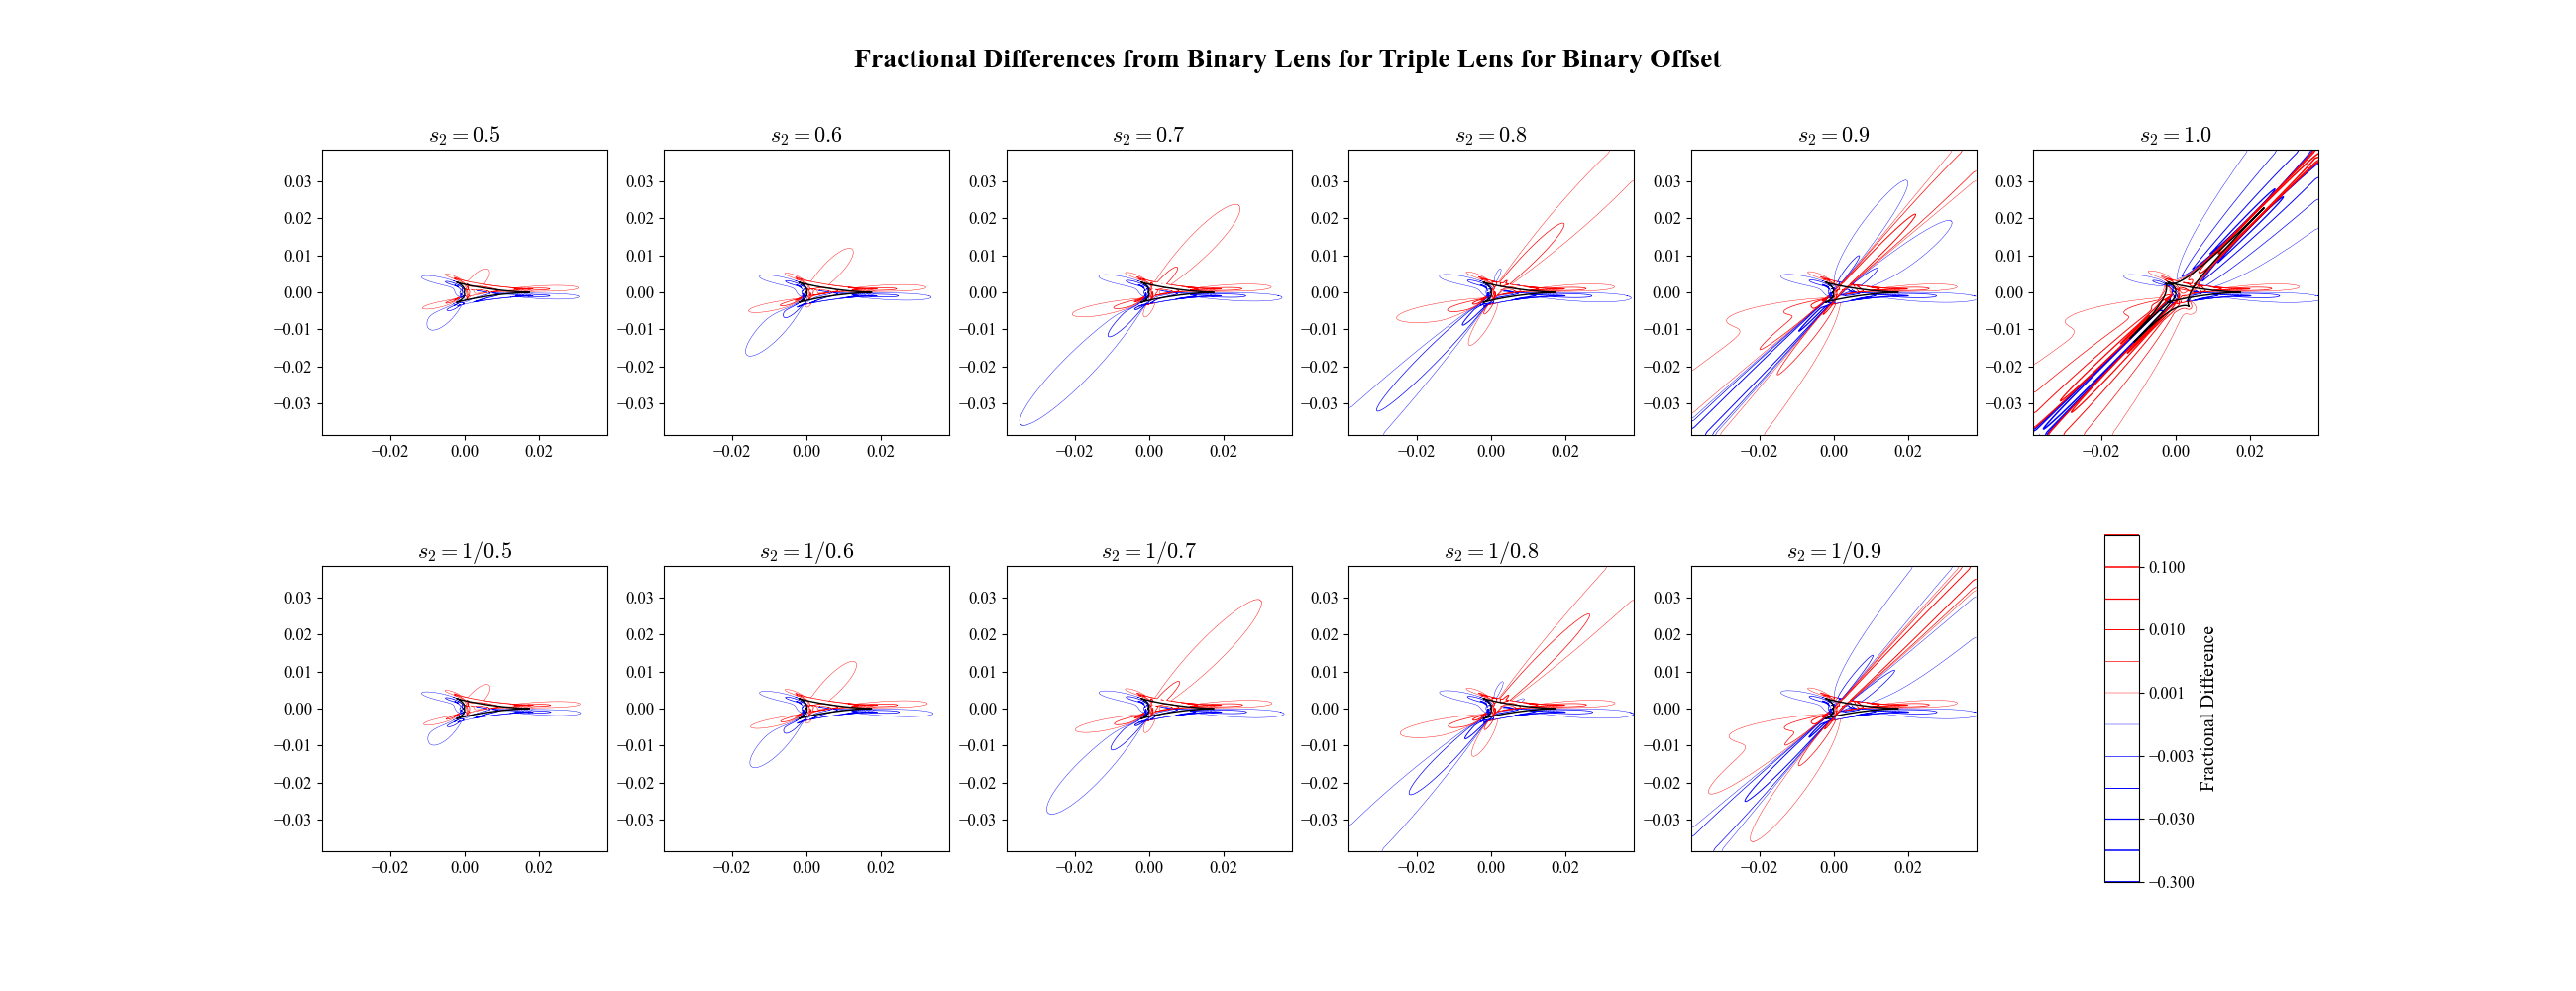

In [101]:
fig = plt.figure(figsize=(26, 10))
axes = fig.subplots(2, 6)

fig.suptitle('Fractional Differences from Binary Lens for Triple Lens for Binary Offset', y=0.95)

for i, ax in enumerate(axes.flatten()):
    if i <= 5:
        ax.set_title(f'$s_2 = {seperations_str[i]}$')

        caustic_points = all_caustic_points[i]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_binary_offset[i], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        ax.set_aspect('equal')
    
    elif i <= 10:
        backwards_i = -i + 16

        ax.set_title(f'$s_2 = {seperations_str[backwards_i]}$')

        caustic_points = all_caustic_points[backwards_i]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_binary_offset[backwards_i], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        ax.set_aspect('equal')
        

    if i == 11:
        cbar_ax = ax
        cbar_ax.axis('off')

        bar = fig.colorbar(img, ax=cbar_ax, fraction=0.75, aspect=10)
        bar.set_label('Fractional Difference')

# fig.savefig('Binary Offset Different S.png', dpi=500)

plt.show()

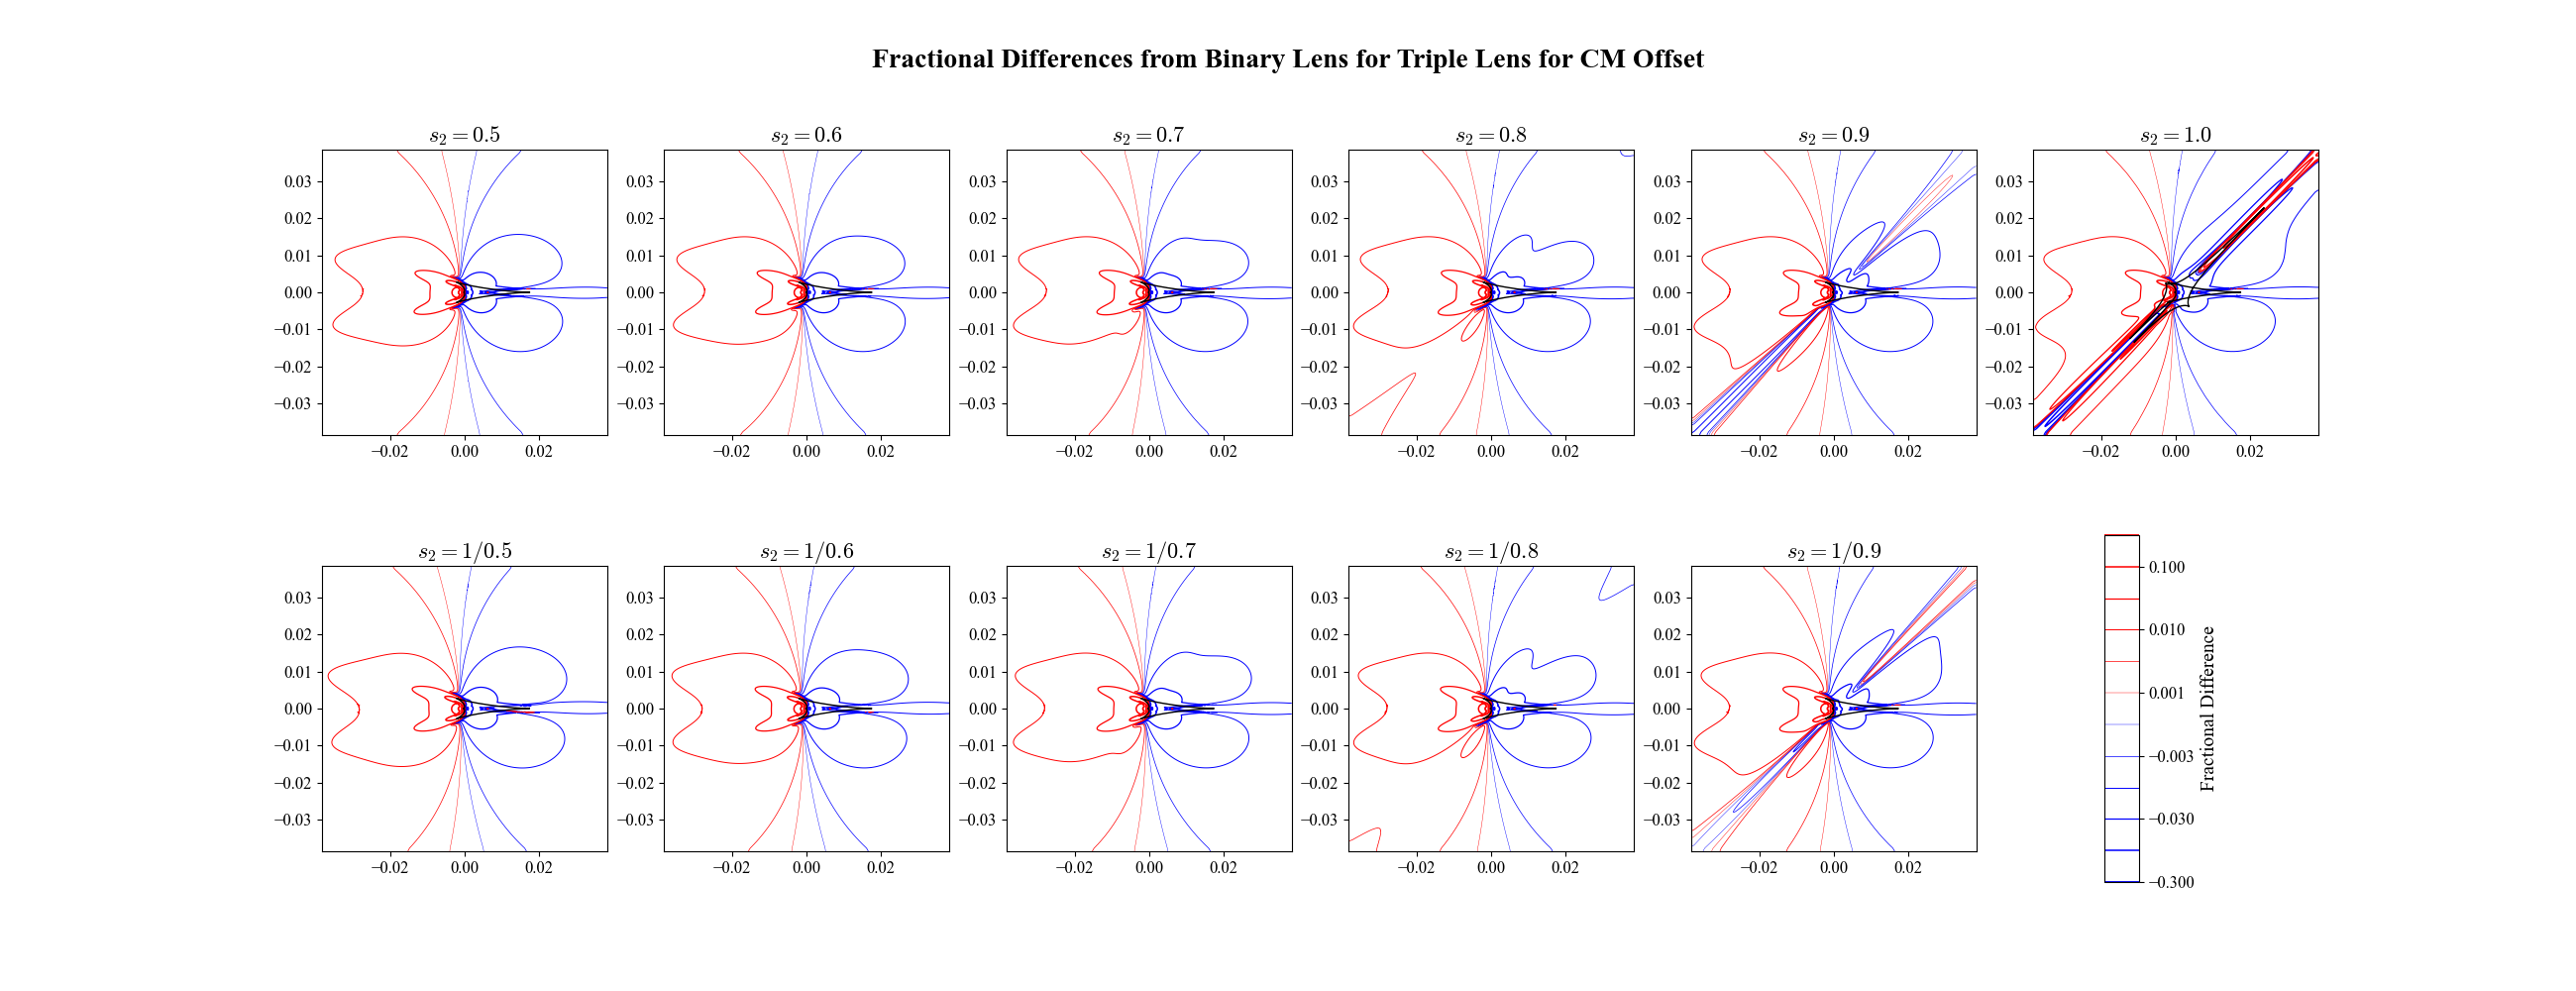

In [102]:
fig = plt.figure(figsize=(26, 10))
axes = fig.subplots(2, 6)

fig.suptitle('Fractional Differences from Binary Lens for Triple Lens for CM Offset', y=0.95)

for i, ax in enumerate(axes.flatten()):
    if i <= 5:
        ax.set_title(f'$s_2 = {seperations_str[i]}$')

        caustic_points = all_caustic_points[i]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_cm_offset[i], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        ax.set_aspect('equal')
    
    elif i <= 10:
        backwards_i = -i + 16

        ax.set_title(f'$s_2 = {seperations_str[backwards_i]}$')

        caustic_points = all_caustic_points[backwards_i]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_cm_offset[backwards_i], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)
        ax.set_aspect('equal')
        

    if i == 11:
        cbar_ax = ax
        cbar_ax.axis('off')

        bar = fig.colorbar(img, ax=cbar_ax, fraction=0.75, aspect=10)
        bar.set_label('Fractional Difference')

# fig.savefig('CM Offset Different S.png', dpi=500)

plt.show()

#### Calculating cumulative distributions to determine the best offset

In [103]:
xs = np.logspace(-5, 0, 100)

cumulative_area_distribution = []
cumulative_area_distribution_binary_offset = []
cumulative_area_distribution_cm_offset = []

for x in xs:
    cumulative_area_distribution.append(np.sum(np.abs(fractional_deviation_binary) < x, axis=(1, 2)) / (pixels**2))
    cumulative_area_distribution_binary_offset.append(np.sum(np.abs(fractional_deviation_binary_binary_offset) < x, axis=(1, 2)) / (pixels**2))
    cumulative_area_distribution_cm_offset.append(np.sum(np.abs(fractional_deviation_binary_cm_offset) < x, axis=(1, 2)) / (pixels**2))

cumulative_area_distribution = np.array(cumulative_area_distribution)
cumulative_area_distribution_binary_offset = np.array(cumulative_area_distribution_binary_offset)
cumulative_area_distribution_cm_offset = np.array(cumulative_area_distribution_cm_offset)

#### Plotting cumulative area distributions

In [104]:
print(cumulative_area_distribution.shape)

(100, 11)


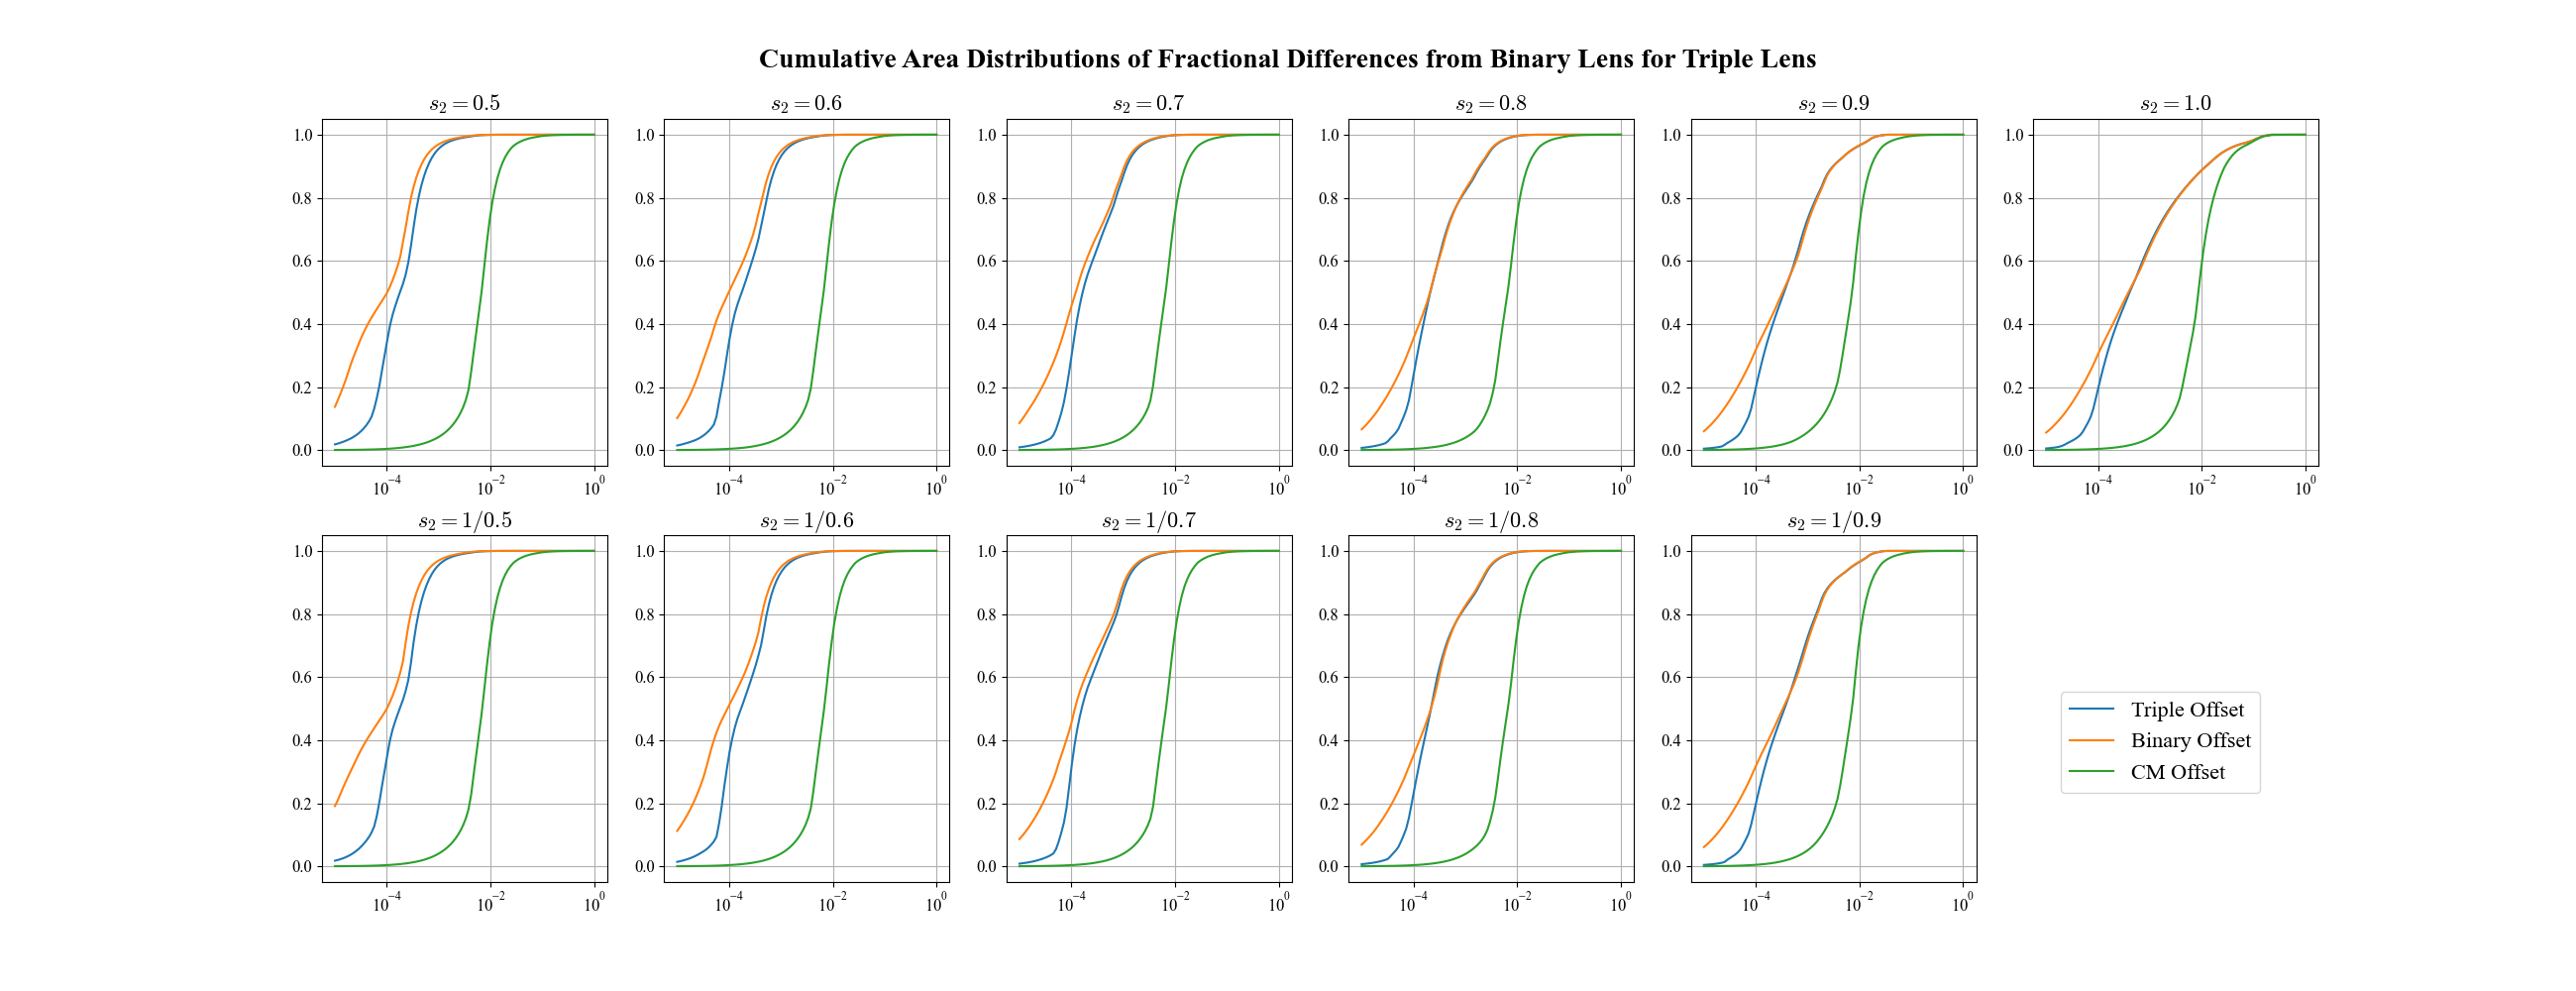

In [105]:
fig = plt.figure(figsize=(26, 10))
axes = fig.subplots(2, 6)

fig.suptitle('Cumulative Area Distributions of Fractional Differences from Binary Lens for Triple Lens', y=0.95)

for i, ax in enumerate(axes.flatten()):
    if i <= 5:
        ax.set_title(f'$s_2 = {seperations_str[i]}$')

        ax.plot(xs, cumulative_area_distribution[:, i], label='Triple Offset')
        ax.plot(xs, cumulative_area_distribution_binary_offset[:, i], label='Binary Offset')
        ax.plot(xs, cumulative_area_distribution_cm_offset[:, i], label='CM Offset')
    
    elif i <= 10:
        backwards_i = -i + 16

        ax.set_title(f'$s_2 = {seperations_str[backwards_i]}$')

        ax.plot(xs, cumulative_area_distribution[:, backwards_i], label='Triple Offset')
        ax.plot(xs, cumulative_area_distribution_binary_offset[:, backwards_i], label='Binary Offset')
        ax.plot(xs, cumulative_area_distribution_cm_offset[:, backwards_i], label='CM Offset')

    if i == 11:
        cbar_ax = ax
        cbar_ax.axis('off')

    ax.set_xscale('log')
    ax.grid(True)

handles, labels = axes[1, 4].get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.8, 0.2), ncol=1, fontsize=16)

# fig.savefig('Different S Cumulative Area Distribution.png', dpi=500)

plt.show()

In [106]:
xs = np.array([1e-4, 1e-3, 1e-2])

cumulative_area_distribution = []
cumulative_area_distribution_binary_offset = []
cumulative_area_distribution_cm_offset = []

for x in xs:
    constant_xs = []
    constant_xs_binary_offset = []
    constant_xs_cm_offset = []

    for i in range(len(seperations)):
        constant_xs.append(np.sum(np.abs(fractional_deviation_binary[i]) < x) / (pixels**2))
        constant_xs_binary_offset.append(np.sum(np.abs(fractional_deviation_binary_binary_offset[i]) < x) / (pixels**2))
        constant_xs_cm_offset.append(np.sum(np.abs(fractional_deviation_binary_cm_offset[i]) < x) / (pixels**2))

    cumulative_area_distribution.append(constant_xs)
    cumulative_area_distribution_binary_offset.append(constant_xs_binary_offset)
    cumulative_area_distribution_cm_offset.append(constant_xs_cm_offset)

cumulative_area_distribution = np.array(cumulative_area_distribution)
cumulative_area_distribution_binary_offset = np.array(cumulative_area_distribution_binary_offset)
cumulative_area_distribution_cm_offset = np.array(cumulative_area_distribution_cm_offset)

In [107]:
print(cumulative_area_distribution.shape)

(3, 11)


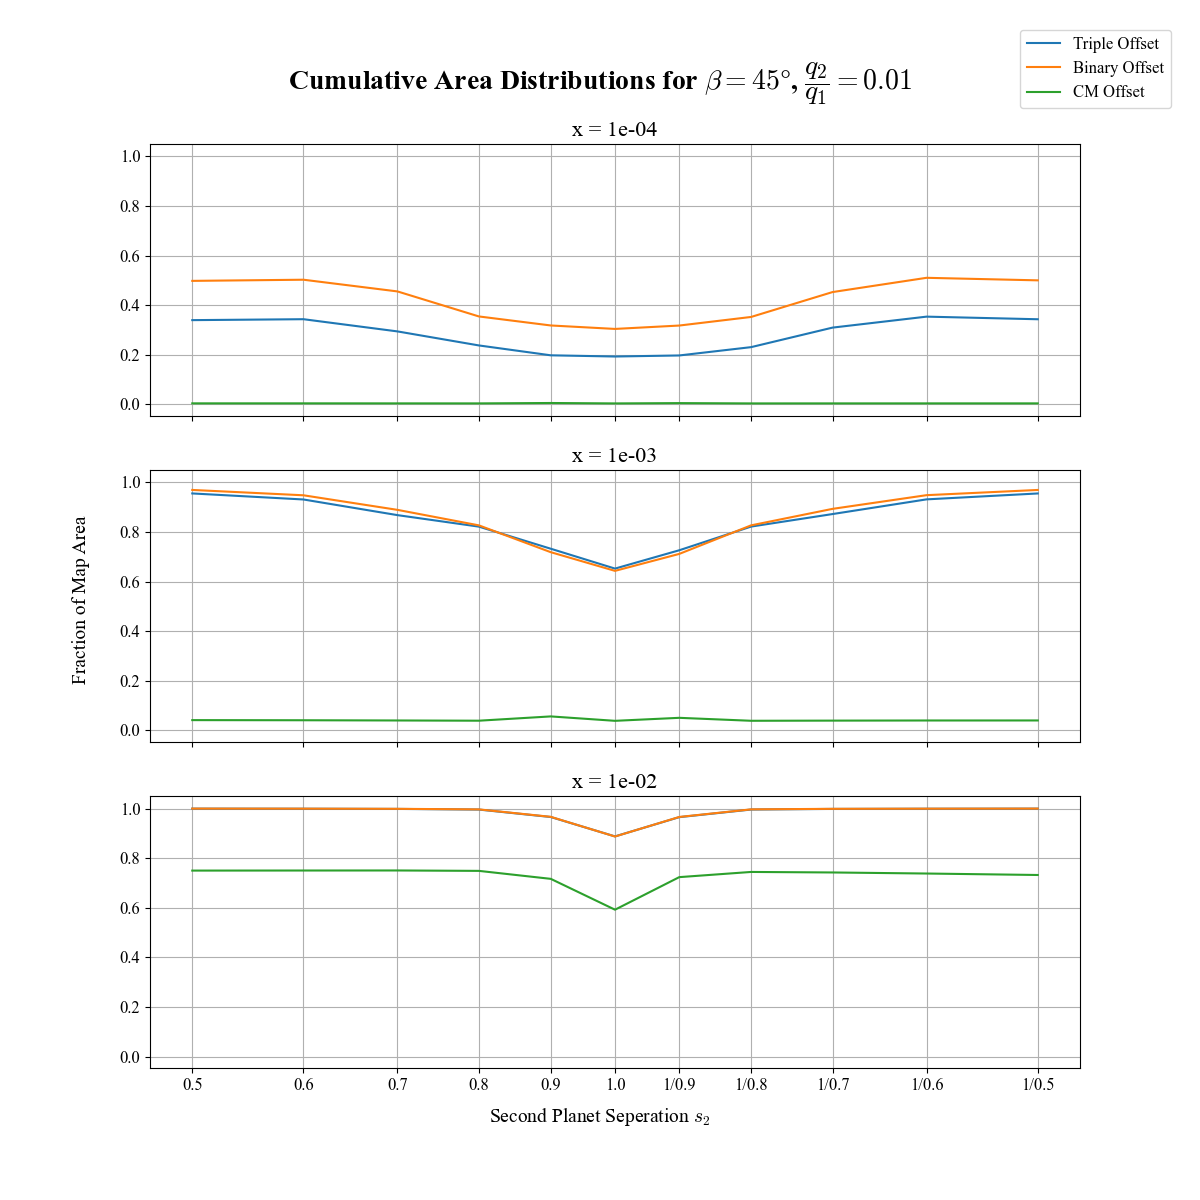

In [108]:
fig = plt.figure(figsize=(12, 12))
axes = fig.subplots(3, 1, sharex=True, sharey=True)

beta_ind = 2

fig.suptitle('Cumulative Area Distributions for $\\beta = 45\degree$, $\\dfrac{q_2}{q_1} = 0.01$', y=0.95)

for i, ax in enumerate(axes):
    ax.set_title(f'x = {xs[i]:.0e}')

    ax.semilogx(seperations, cumulative_area_distribution[i, :], label='Triple Offset')
    ax.semilogx(seperations, cumulative_area_distribution_binary_offset[i, :], label='Binary Offset')
    ax.semilogx(seperations, cumulative_area_distribution_cm_offset[i, :], label='CM Offset')

    ax.set_xticks(seperations)
    ax.set_xticklabels(seperations_str)
    ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.85, 0.91), ncol=1, fontsize=12)

fig.supxlabel('Second Planet Seperation $s_2$', y=0.06)
fig.supylabel('Fraction of Map Area', x=0.06)

# fig.savefig('Cumulative Distributions Varying Sep.png', dpi=500)

plt.show()

#### Generating light curves

In [109]:
# Distribution of impact parameters and angle with respect to binary axis
us = np.linspace(0, ang_width/2, 21)
alphas = np.linspace(-180, 180, 9)

print(us)
print(alphas)

brightness_distribution = []
brightness_distribution_binary_offset = []
brightness_distribution_cm_offset = []
binary_brightness_distribution = []

time_distribution = []
x_distribution = []
y_distribution = []

for i, triple_lens in enumerate(triple_lenses):
    constant_seperation = []
    constant_seperation_binary_offset = []
    constant_seperation_cm_offset = []
    binary_constant_seperation = []

    constant_seperation_times = []
    constant_seperation_x = []
    constant_seperation_y = []

    for u in us:
        constant_u = []
        constant_u_binary_offset = []
        constant_u_cm_offset = []
        binary_constant_u = []

        constant_u_times = []
        constant_u_x = []
        constant_u_y = []

        for alpha in alphas:
            intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_triple_lenses[i])
            constant_u.append(brightness)

            intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_triple_lenses_binary_offset[i])
            constant_u_binary_offset.append(brightness)
            
            intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_triple_lenses_cm_offset[i])
            constant_u_cm_offset.append(brightness)

            intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_binary_lens)
            binary_constant_u.append(brightness)
            
            constant_u_times.append(times)
            constant_u_x.append(xs)
            constant_u_y.append(ys)
        
        constant_seperation.append(constant_u)
        constant_seperation_binary_offset.append(constant_u_binary_offset)
        constant_seperation_cm_offset.append(constant_u_cm_offset)
        binary_constant_seperation.append(binary_constant_u)

        constant_seperation_times.append(constant_u_times)
        constant_seperation_x.append(constant_u_x)
        constant_seperation_y.append(constant_u_y)

    brightness_distribution.append(constant_seperation)
    brightness_distribution_binary_offset.append(constant_seperation_binary_offset)
    brightness_distribution_cm_offset.append(constant_seperation_cm_offset)
    binary_brightness_distribution.append(binary_constant_seperation)

    time_distribution.append(constant_seperation_times)
    x_distribution.append(constant_seperation_x)
    y_distribution.append(constant_seperation_y)


[0.         0.00192008 0.00384016 0.00576024 0.00768032 0.0096004
 0.01152048 0.01344056 0.01536064 0.01728072 0.0192008  0.02112088
 0.02304096 0.02496104 0.02688112 0.0288012  0.03072128 0.03264136
 0.03456144 0.03648152 0.0384016 ]
[-180. -135.  -90.  -45.    0.   45.   90.  135.  180.]


/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:1370: RuntimeWarning: divide by zero encountered in scalar divide
  t = (y_edge - y0) / dy
/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:1370: RuntimeWarning: invalid value encountered in scalar divide
  t = (y_edge - y0) / dy


In [110]:
brightness_distribution = np.array(brightness_distribution, dtype=np.ndarray)
brightness_distribution_binary_offset = np.array(brightness_distribution_binary_offset, dtype=np.ndarray)
brightness_distribution_cm_offset = np.array(brightness_distribution_cm_offset, dtype=np.ndarray)
binary_brightness_distribution = np.array(binary_brightness_distribution, dtype=np.ndarray)

time_distribution = np.array(time_distribution, dtype=np.ndarray)
x_distribution = np.array(x_distribution, dtype=np.ndarray)
y_distribution = np.array(y_distribution, dtype=np.ndarray)

print(brightness_distribution.shape)
print(brightness_distribution_binary_offset.shape)
print(brightness_distribution_cm_offset.shape)
print(binary_brightness_distribution.shape)

print(time_distribution.shape)
print(x_distribution.shape)
print(y_distribution.shape)

(11, 21, 9)
(11, 21, 9)
(11, 21, 9)
(11, 21, 9)
(11, 21, 9)
(11, 21, 9)
(11, 21, 9)


In [111]:
VB_magnifications = []
VB_xs = []
VB_ys = []

# Calculating light curve for binary lens
for i, u in enumerate(us):
    constant_u = []
    constant_u_xs = []
    constant_u_ys = []

    for j, alpha in enumerate(alphas):
        s = 0.8
        q = 1e-3
        u0 = -u
        alpha = np.deg2rad(alpha)
        rho = radius
        tE = 1.0
        t0 = 0

        # Array of parameters for the light curve
        parameters = [np.log(s), np.log(q), u0, alpha, np.log(rho), np.log(tE), t0]

        t = np.flip(time_distribution[0][i, j])
        # t = np.linspace(-1, 1, 1000)

        magnification, y1, y2 = VBM.BinaryLightCurve(parameters, t)
        constant_u.append(magnification)
        constant_u_xs.append(y1)
        constant_u_ys.append(y2)
    
    VB_magnifications.append(constant_u)
    VB_xs.append(constant_u_xs)
    VB_ys.append(constant_u_ys)

#### Choosing what light curve to plot

In [112]:
ind_u = 2
ind_alpha = 5

print(f'u = {us[ind_u]:.5f}')
print(f'alpha = {alphas[ind_alpha]:.3f} degrees')

u = 0.00384
alpha = 45.000 degrees


[-0.038401598401598416, -0.038363164157831274, -0.038324729914064146, -0.03828629567029701, -0.03824786142652988, -0.038209427182762754, -0.03817099293899562, -0.03813255869522849, -0.038094124451461354, -0.038055690207694226, -0.03801725596392709, -0.03797882172015996, -0.03794038747639283, -0.037901953232625706, -0.03786351898885858, -0.03782508474509144, -0.03778665050132431, -0.03774821625755718, -0.03770978201379005, -0.03767134777002292, -0.037632913526255786, -0.03759447928248866, -0.03755604503872152, -0.037517610794954394, -0.03747917655118726, -0.03744074230742013, -0.037402308063652995, -0.037363873819885866, -0.03732543957611873, -0.0372870053323516, -0.03724857108858448, -0.03721013684481735, -0.03717170260105022, -0.03713326835728309, -0.037094834113515954, -0.037056399869748825, -0.03701796562598169, -0.03697953138221456, -0.036941097138447426, -0.0369026628946803, -0.03686422865091316, -0.036825794407146034, -0.0367873601633789, -0.03674892591961177, -0.0367104916758446

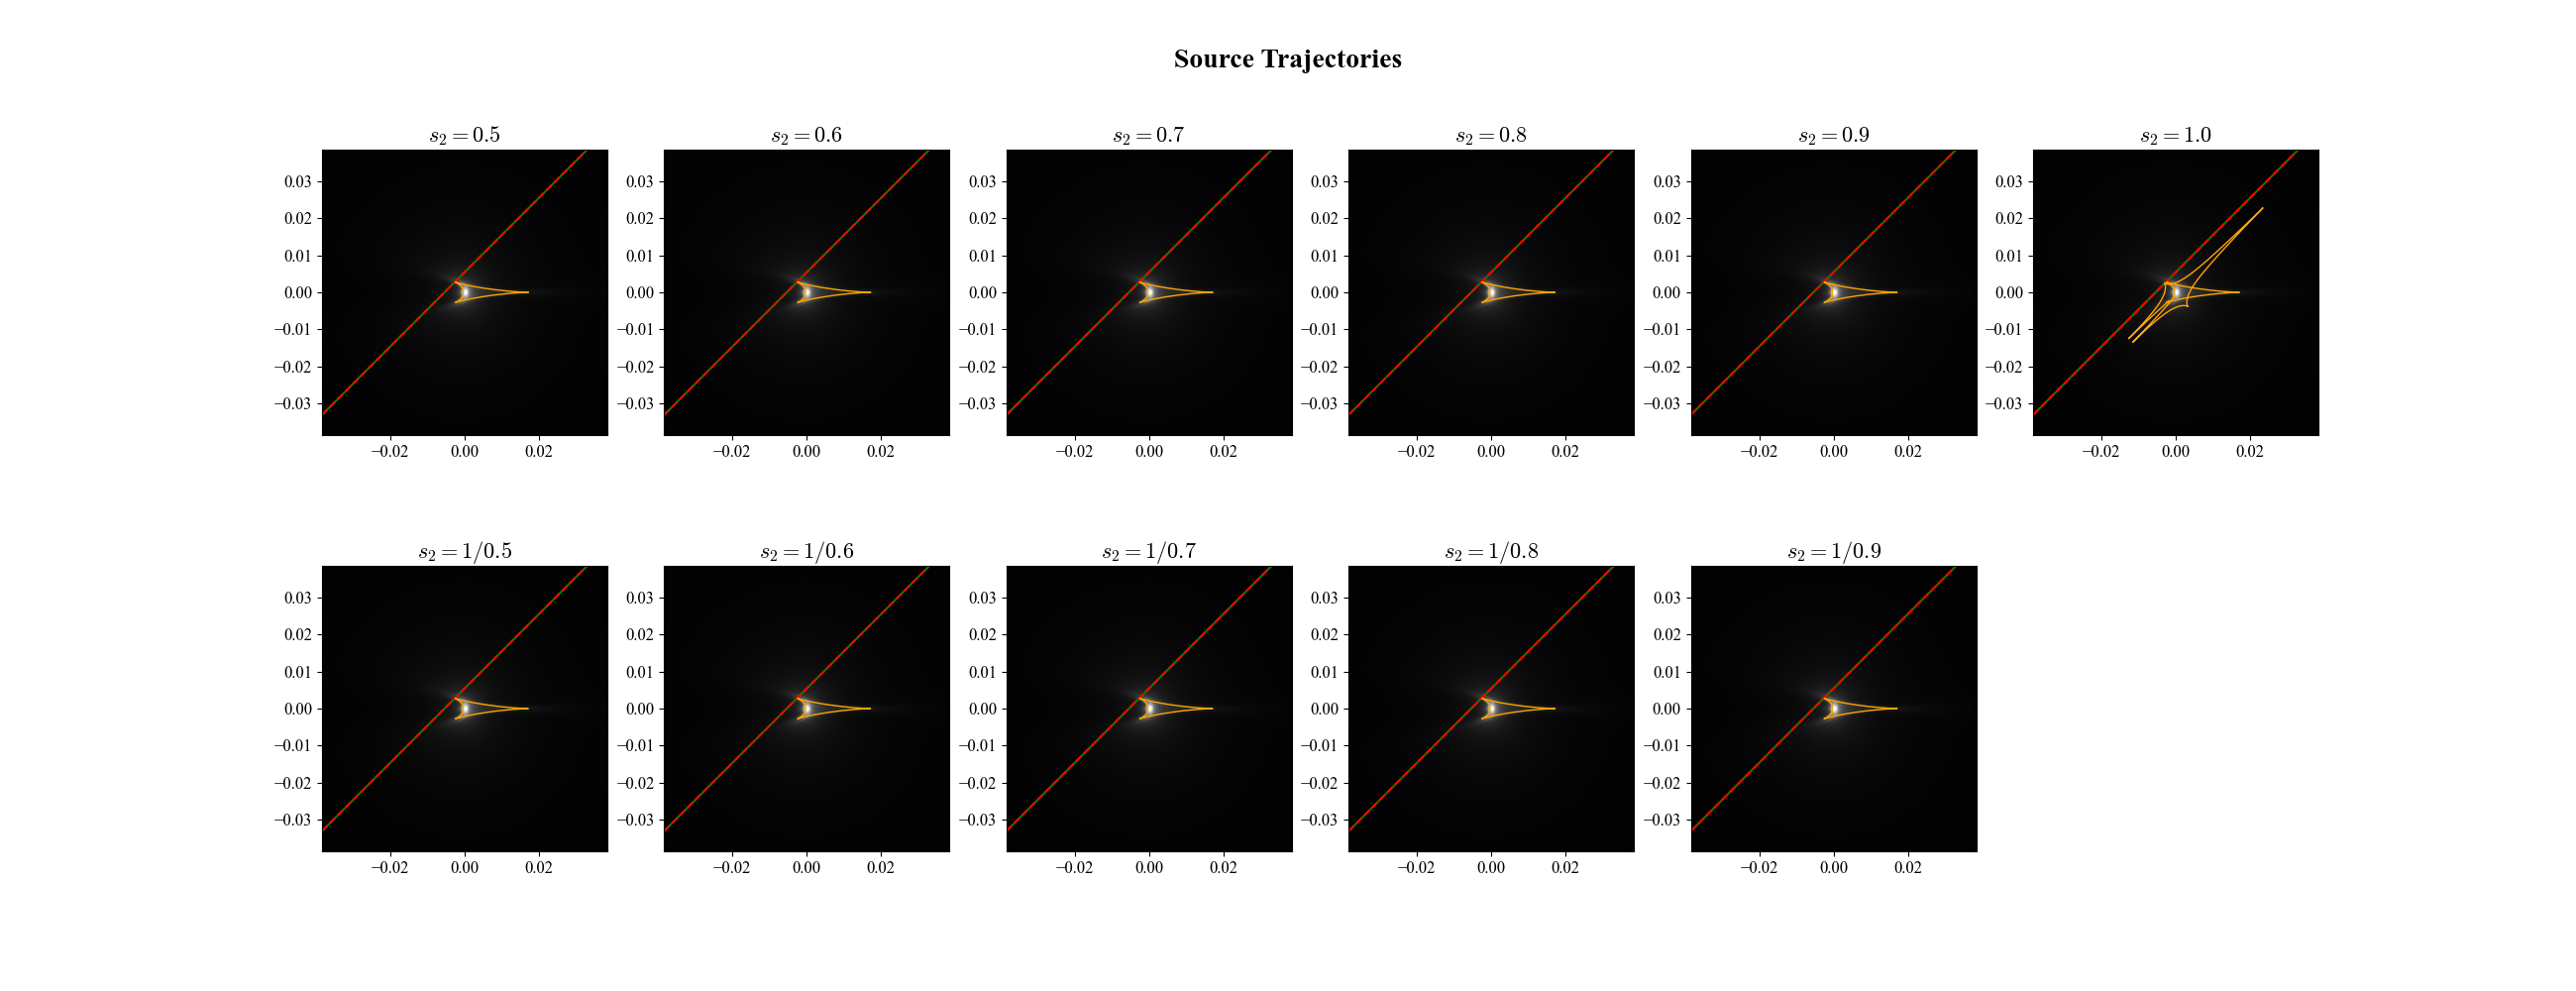

In [113]:
fig = plt.figure(figsize=(26, 10))
axes = fig.subplots(2, 6)

fig.suptitle('Source Trajectories', y=0.95)

for i, ax in enumerate(axes.flatten()):
    if i <= 5:
        ax.set_title(f'$s_2 = {seperations_str[i]}$')

        caustic_points = all_caustic_points_cm_offset[i]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='orange', linewidth=1, zorder=10)

        ax.imshow(convolved_triple_lenses[i], cmap='gray', extent=[-ang_width/2, ang_width/2, -ang_width/2, ang_width/2])

        one_configuration_xs = x_distribution[i]
        one_configuration_ys = y_distribution[i]

        xs = one_configuration_xs[ind_u, ind_alpha]
        ys = one_configuration_ys[ind_u, ind_alpha]

        ax.plot(xs, ys, color='green')
        ax.plot(VB_xs[ind_u][ind_alpha], VB_ys[ind_u][ind_alpha], linestyle='--', color='red')
        print(VB_xs[ind_u][ind_alpha])
    
    elif i <= 10:
        backwards_i = -i + 16

        ax.set_title(f'$s_2 = {seperations_str[backwards_i]}$')

        caustic_points = all_caustic_points_cm_offset[backwards_i]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='orange', linewidth=1, zorder=10)

        ax.imshow(convolved_triple_lenses[backwards_i], cmap='gray', extent=[-ang_width/2, ang_width/2, -ang_width/2, ang_width/2])

        one_configuration_xs = x_distribution[backwards_i]
        one_configuration_ys = y_distribution[backwards_i]

        xs = one_configuration_xs[ind_u, ind_alpha]
        ys = one_configuration_ys[ind_u, ind_alpha]

        ax.plot(xs, ys, color='green')
        ax.plot(VB_xs[ind_u][ind_alpha], VB_ys[ind_u][ind_alpha], linestyle='--', color='red')
        print(VB_xs[ind_u][ind_alpha])

    if i == 11:
        cbar_ax = ax
        cbar_ax.axis('off')

    ax.set_xlim(-ang_width/2, ang_width/2)
    ax.set_ylim(-ang_width/2, ang_width/2)

plt.show()

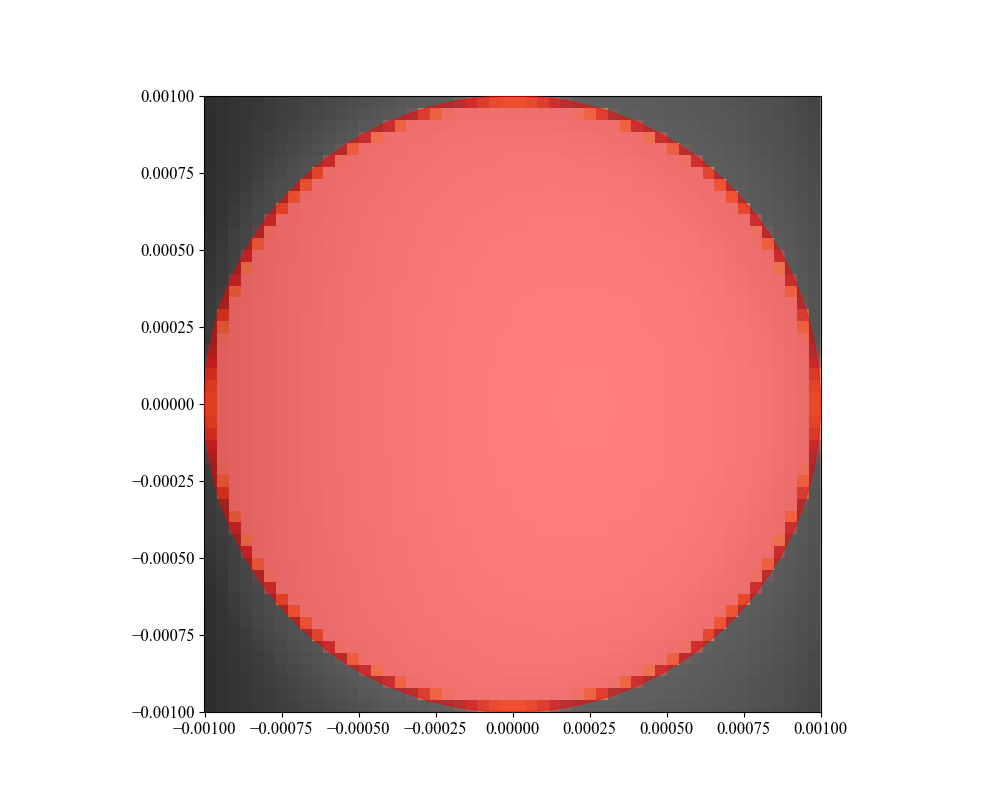

In [114]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(convolved_binary_lens, cmap='gray', extent=[-ang_width/2, ang_width/2, -ang_width/2, ang_width/2])
ax.imshow(source_profile, cmap='afmhot', extent=[-radius, radius, -radius, radius], alpha=0.5)

bounds = 1*radius

ax.set_xlim(-bounds, bounds)
ax.set_ylim(-bounds, bounds)

source_patch = patches.Circle((0, 0), radius, color='red', alpha=0.5, label='Source', zorder=10)
ax.add_patch(source_patch)

plt.show()

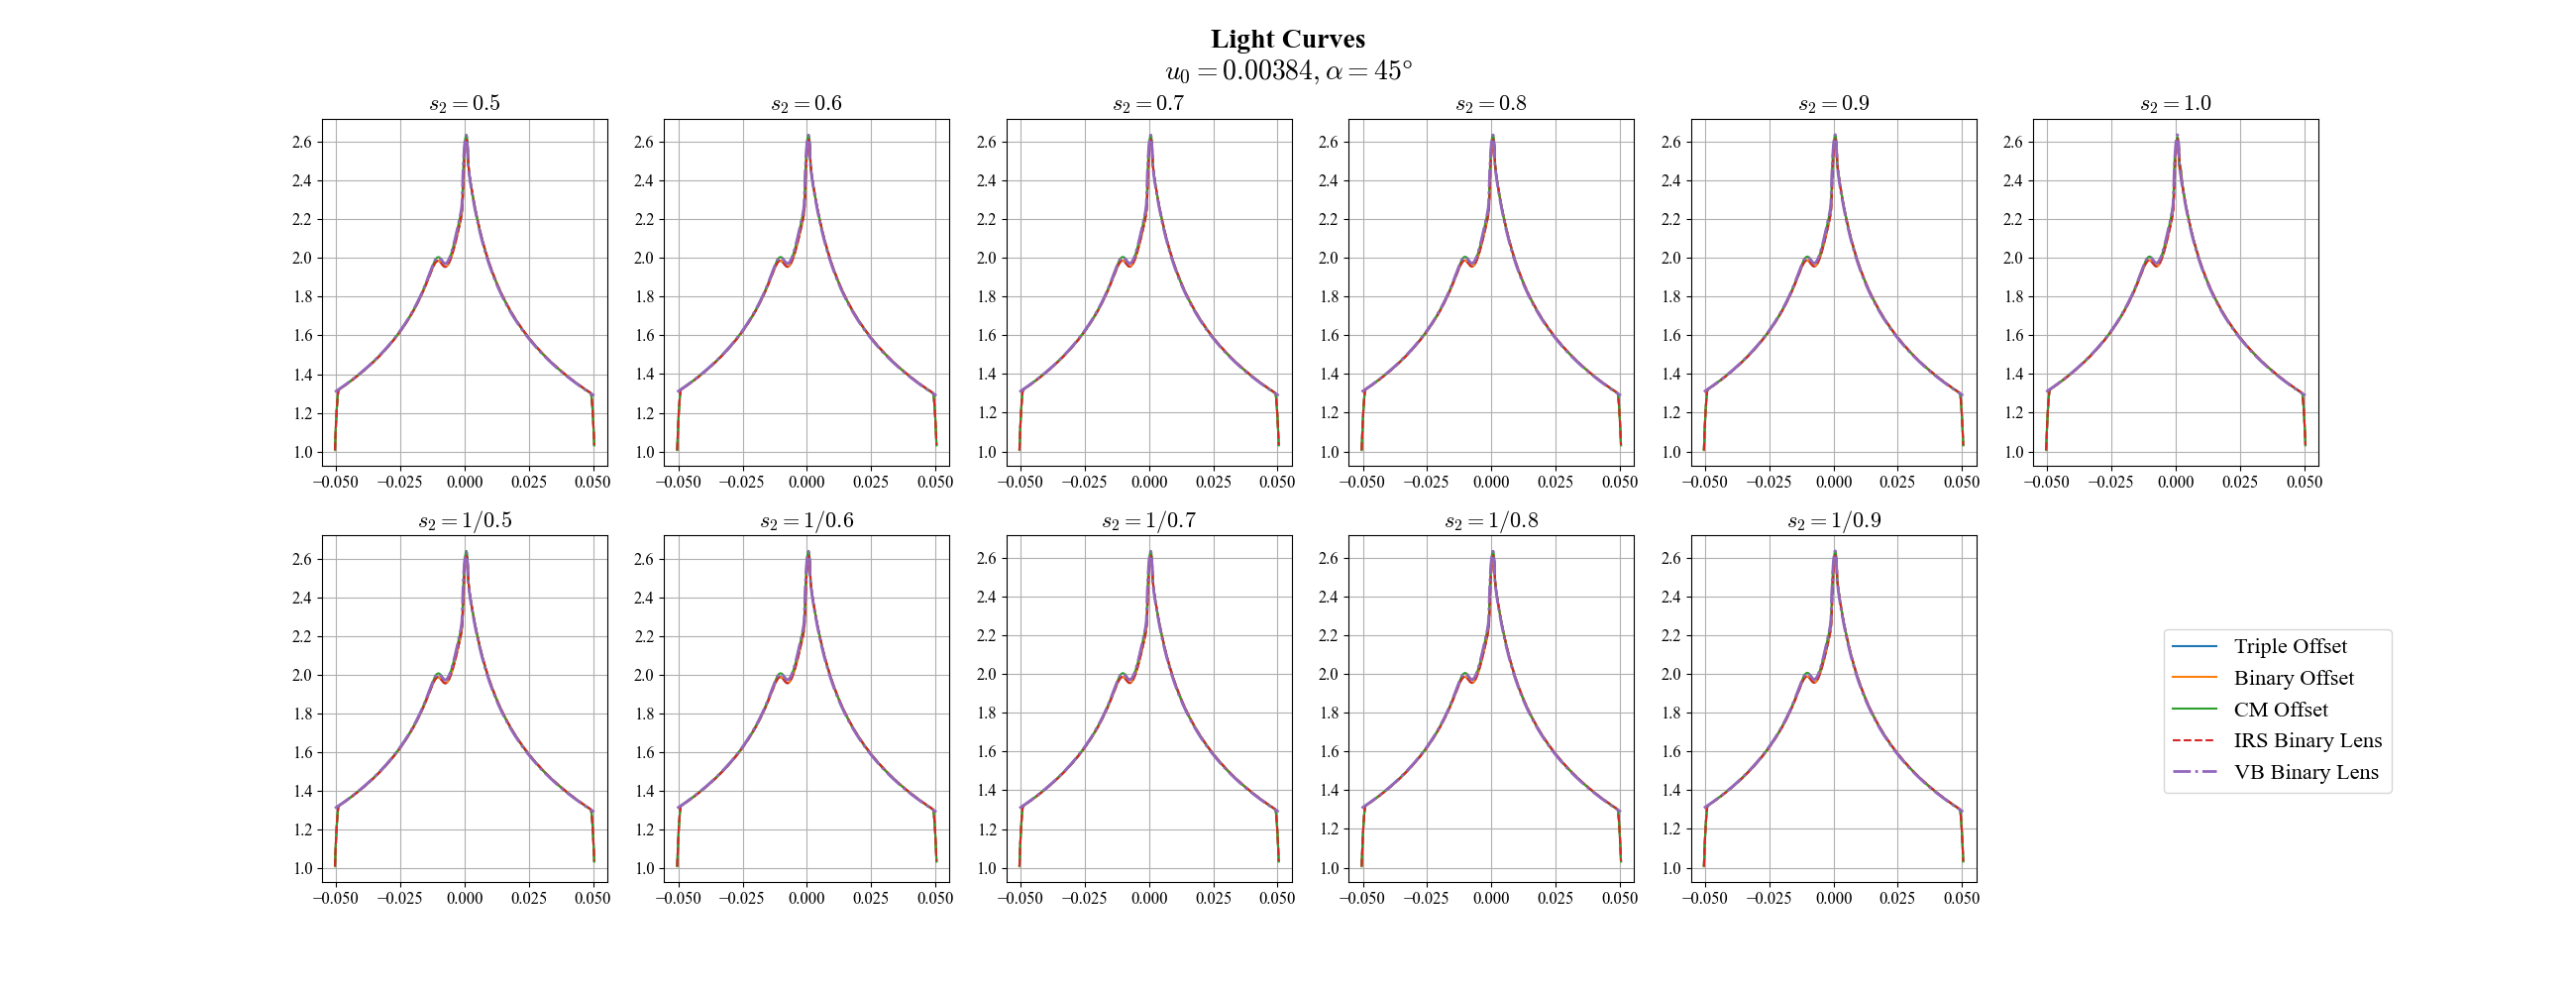

In [115]:
fig = plt.figure(figsize=(26, 10))
axes = fig.subplots(2, 6)

fig.suptitle(f'Light Curves\n$u_0 = {us[ind_u]:.5f}, \\alpha = {alphas[ind_alpha]:.0f}\degree$', y=0.97)

for i, ax in enumerate(axes.flatten()):
    if i <= 5:
        ax.set_title(f'$s_2 = {seperations_str[i]}$')

        one_configuration_brightness = brightness_distribution[i]
        one_configuration_brightness_binary_offset = brightness_distribution_binary_offset[i]
        one_configuration_brightness_cm_offset = brightness_distribution_cm_offset[i]
        binary_one_configuration_brightness = binary_brightness_distribution[i]

        one_configuration_times = time_distribution[i]

        brightness = one_configuration_brightness[ind_u, ind_alpha]
        brightness_binary_offset = one_configuration_brightness_binary_offset[ind_u, ind_alpha]
        brightness_cm_offset = one_configuration_brightness_cm_offset[ind_u, ind_alpha]
        binary_brightness = binary_one_configuration_brightness[ind_u, ind_alpha]
        
        times = one_configuration_times[ind_u, ind_alpha]

        ax.plot(times, np.log10(brightness), label='Triple Offset')
        ax.plot(times, np.log10(brightness_binary_offset), label='Binary Offset')
        ax.plot(times, np.log10(brightness_cm_offset), label='CM Offset')
        ax.plot(times, np.log10(binary_brightness), label='IRS Binary Lens', linestyle='--')

        ax.plot(times, np.log10(np.array(VB_magnifications[ind_u][ind_alpha])), label='VB Binary Lens', linestyle='-.', linewidth=2)

    elif i <= 10:
        backwards_i = -i + 16

        ax.set_title(f'$s_2 = {seperations_str[backwards_i]}$')

        one_configuration_brightness = brightness_distribution[backwards_i]
        one_configuration_brightness_binary_offset = brightness_distribution_binary_offset[backwards_i]
        one_configuration_brightness_cm_offset = brightness_distribution_cm_offset[backwards_i]
        binary_one_configuration_brightness = binary_brightness_distribution[backwards_i]

        one_configuration_times = time_distribution[backwards_i]

        brightness = one_configuration_brightness[ind_u, ind_alpha]
        brightness_binary_offset = one_configuration_brightness_binary_offset[ind_u, ind_alpha]
        brightness_cm_offset = one_configuration_brightness_cm_offset[ind_u, ind_alpha]
        binary_brightness = binary_one_configuration_brightness[ind_u, ind_alpha]
        
        times = one_configuration_times[ind_u, ind_alpha]

        ax.plot(times, np.log10(brightness), label='Triple Offset')
        ax.plot(times, np.log10(brightness_binary_offset), label='Binary Offset')
        ax.plot(times, np.log10(brightness_cm_offset), label='CM Offset')
        ax.plot(times, np.log10(binary_brightness), label='IRS Binary Lens', linestyle='--')

        ax.plot(times, np.log10(np.array(VB_magnifications[ind_u][ind_alpha])), label='VB Binary Lens', linestyle='-.', linewidth=2)

    elif i == 11:
        cbar_ax = ax
        cbar_ax.axis('off')

    ax.grid(True)

handles, labels = axes[1, 4].get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.84, 0.2), ncol=1, fontsize=16)

plt.show()

In [116]:
denominator = 1

In [117]:
s = 0.8
q = 1e-3
u0 = -us[ind_u]
alpha = np.deg2rad(alphas[ind_alpha])
rho = radius/denominator
tE = 1.0
t0 = 0

VBM.SetLDprofile(VBM.LDlinear)
VBM.a1 = 0

# Array of parameters for the light curve
parameters = [np.log(s), np.log(q), u0, alpha, np.log(rho), np.log(tE), t0]

t = np.flip(time_distribution[0][ind_u, ind_alpha])
# t = np.linspace(-1, 1, 1000)

magnification, y1, y2 = VBM.BinaryLightCurve(parameters, t)
magnification = np.array(magnification)

In [118]:
mm_param_dict = {'t_0': 0, 't_E': 1, 'u_0': -u0, 'rho': radius/denominator, 'q': q, 'alpha': alphas[ind_alpha], 's': s}
model = mm.Model(mm_param_dict)

model.set_default_magnification_method('VBBL')

analytic_mags = model.get_magnification(times, gamma=0.5)

[]

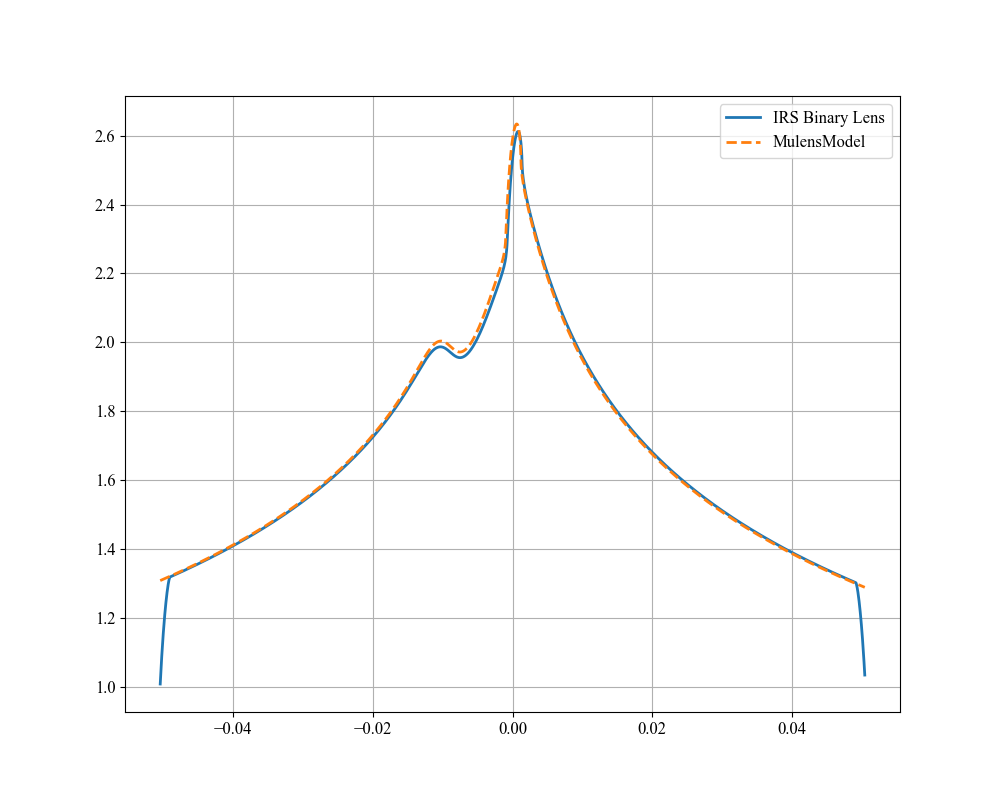

In [119]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.plot(times, np.log10(binary_brightness), label='IRS Binary Lens', linestyle='-', linewidth=2)
# ax.plot(times, np.log10(brightness), label='IRS Triple Lens', linestyle='-', linewidth=2)

# ax.plot(times, np.log10(magnification), label='VB Binary Lens', linestyle='-.', linewidth=2)
ax.plot(times, np.log10(analytic_mags), label='MulensModel', linestyle='--', linewidth=2)

ax.legend()

ax.grid(True)

plt.plot()

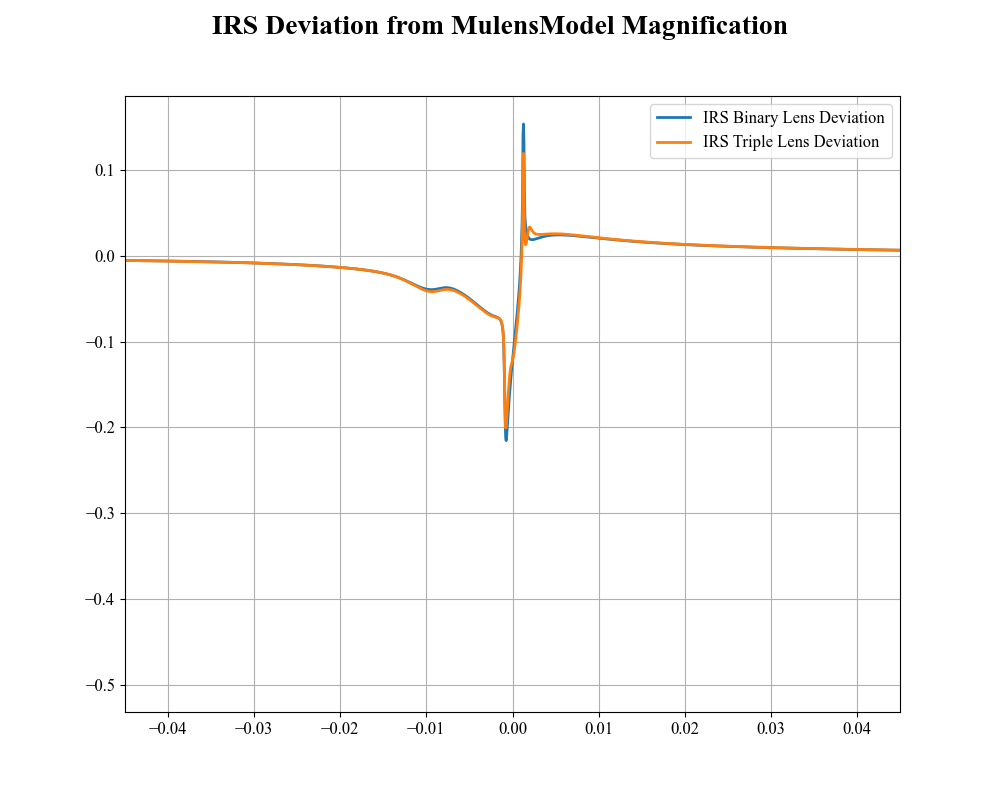

In [120]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('IRS Deviation from MulensModel Magnification')

deviation = (binary_brightness - analytic_mags) / analytic_mags
deviation2 = (brightness - analytic_mags) / analytic_mags

ax.plot(times, deviation, label='IRS Binary Lens Deviation', linestyle='-', linewidth=2)
ax.plot(times, deviation2, label='IRS Triple Lens Deviation', linestyle='-', linewidth=2)

ax.grid(True)

ax.set_xlim(-0.045, 0.045)

ax.legend()

plt.show()